# Do Banks' Disclosed VaR Figures Hold Up?
## An Empirical Audit of 10-Q Backtesting Disclosures

*Research notebook mirroring the structure of the SSRN paper.*

Under the Basel III internal-models approach, large banks compute market-risk
capital from internal one-day Value-at-Risk (VaR) models and must backtest them
against 250 days of P&L under the supervisory traffic-light system. U.S.
securities regulation simultaneously forces those same banks to *publish*
average, high, and low one-day trading VaR in every 10-Q and 10-K. This
notebook performs an independent, outside audit of those disclosures for five
large U.S. dealers — JPMorgan Chase, Goldman Sachs, Morgan Stanley, Bank of
America, and Citigroup — over 2019–2024, a window spanning the COVID-19 crash,
the 2022 rates repricing, and the March 2023 regional-banking stress.

**Hypothesis.** Disclosed VaR is conservatively calibrated on average
(unconditional coverage holds), but violations cluster in high-VIX regimes
because quarterly-average disclosures adapt too slowly — so Christoffersen's
independence and conditional-coverage tests reject even where Kupiec's level
test does not.


In [1]:
# Setup: run everything from the project root.
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import os
os.chdir(ROOT)

import pandas as pd
from IPython.display import Image, display

import config
config.ensure_dirs()
print('Project root:', ROOT)


Project root: /home/user/var-confidence-audit


## 1. Data

Three sources are combined. **Market data**: daily adjusted close prices and
log returns for the five tickers plus the VIX, via yfinance; two macro context
series (high-yield OAS, fed funds upper bound) via FRED. **Disclosures**: every
in-sample 10-Q/10-K is pulled from SEC EDGAR (submissions API, cross-checked
with full-text search), parsed with BeautifulSoup, and the trading-VaR table
extracted by regex; quarters that cannot be machine-read are linearly
interpolated and flagged. Scraping respects SEC fair-access rules (declared
User-Agent, 2-second spacing, exponential backoff).


In [2]:
# Fetch market data (skips gracefully if files already exist on disk).
from data import fetch

if not (config.RAW_DIR / 'bank_returns.csv').exists():
    fetch.main()
returns = pd.read_csv(config.RAW_DIR / 'bank_returns.csv', index_col='date', parse_dates=True)
returns.describe().T


,count,mean,std,min,25%,50%,75%,max
JPM,1509.0,0.000700,0.019264,-0.162106,-0.007817,0.000957,0.009347,0.165620
GS,1509.0,0.000892,0.019931,-0.135880,-0.008748,0.000641,0.011013,0.161951
MS,1509.0,0.000878,0.021299,-0.169603,-0.009033,0.000957,0.011518,0.180404
BAC,1509.0,0.000472,0.021339,-0.167205,-0.009696,0.000383,0.010648,0.163786
C,1509.0,0.000326,0.023429,-0.214414,-0.010329,0.000391,0.011027,0.165381


In [3]:
# Scrape EDGAR VaR disclosures (slow: ~120 filings at 2s spacing).
if not (config.RAW_DIR / 'var_disclosures.csv').exists():
    import data.scrape_edgar as scrape_edgar
    sys.argv = ['scrape_edgar.py']  # avoid Jupyter's kernel argv leaking into argparse
    scrape_edgar.main()
disclosures = pd.read_csv(config.RAW_DIR / 'var_disclosures.csv', parse_dates=['period_end'])
disclosures.groupby('bank')[['var_1day_avg_mm']].describe()


var_1day_avg_mm                                                        \
               count        mean        std   min       25%    50%     75%   
bank                                                                         
BAC             24.0   99.000000  44.241432  34.0   74.7500   91.0  120.75   
C               24.0  108.041667  28.836087  54.0  100.5000  109.0  126.50   
GS              24.0   88.744583  20.763263  52.0   79.8125   90.5   98.25   
JPM             24.0   58.583333  23.149639  36.0   45.7500   50.0   58.25   
MS              24.0   57.916667  10.549744  41.0   50.0000   56.0   63.00   

             
        max  
bank         
BAC   195.0  
C     155.0  
GS    130.0  
JPM   130.0  
MS     76.0

The table above summarizes the disclosed one-day trading VaR panel: 24
quarters per bank, with the stated confidence level (95% for JPM/GS/MS, 99%
for BAC/C), methodology, and the interpolation flag. Note the COVID-era jump
in average VaR across all five banks during 2020.


## 2. Violation analysis

Disclosed dollar VaR is normalized into return space by dividing by a
trading-equity base (market cap × fixed per-bank trading intensity), and a
violation is a day where the absolute daily log return exceeds the threshold —
a deliberately conservative definition, flagged in the paper's caveats.


In [4]:
from analysis import violations
violations.main()
summary = pd.read_csv(config.PROCESSED_DIR / 'violation_summary.csv')
summary[summary['period'] == 'full_sample']


2026-06-10 18:07:59 | INFO    | analysis.violations | Loaded 1509 return days, 120 disclosure rows


2026-06-10 18:07:59 | INFO    | analysis.violations | Saved daily panel (7545 rows) to /home/user/var-confidence-audit/data/processed/daily_violations.csv


2026-06-10 18:07:59 | INFO    | analysis.violations | Saved violation summary (135 rows) to /home/user/var-confidence-audit/data/processed/violation_summary.csv


2026-06-10 18:07:59 | INFO    | analysis.violations | BAC: actual 1.52% vs expected 1.00% (23 violations / 1509 days)


2026-06-10 18:07:59 | INFO    | analysis.violations | C: actual 1.46% vs expected 1.00% (22 violations / 1509 days)


...

2026-06-10 18:08:00 | INFO    | analysis.violations | Saved /home/user/var-confidence-audit/outputs/figures/violation_calendar_MS.png


2026-06-10 18:08:01 | INFO    | analysis.violations | Saved /home/user/var-confidence-audit/outputs/figures/violation_calendar_BAC.png


2026-06-10 18:08:01 | INFO    | analysis.violations | Saved /home/user/var-confidence-audit/outputs/figures/violation_calendar_C.png


2026-06-10 18:08:01 | INFO    | analysis.violations | Violation analysis complete.


,bank,period,stated_conf,actual_violation_rate,expected_rate,excess_rate,n_violations,n_trading_days
120,BAC,full_sample,0.99,0.015242,0.01,0.005242,23.0,1509.0
121,C,full_sample,0.99,0.014579,0.01,0.004579,22.0,1509.0
122,GS,full_sample,0.95,0.062956,0.05,0.012956,95.0,1509.0
123,JPM,full_sample,0.95,0.063618,0.05,0.013618,96.0,1509.0
124,MS,full_sample,0.95,0.076872,0.05,0.026872,116.0,1509.0


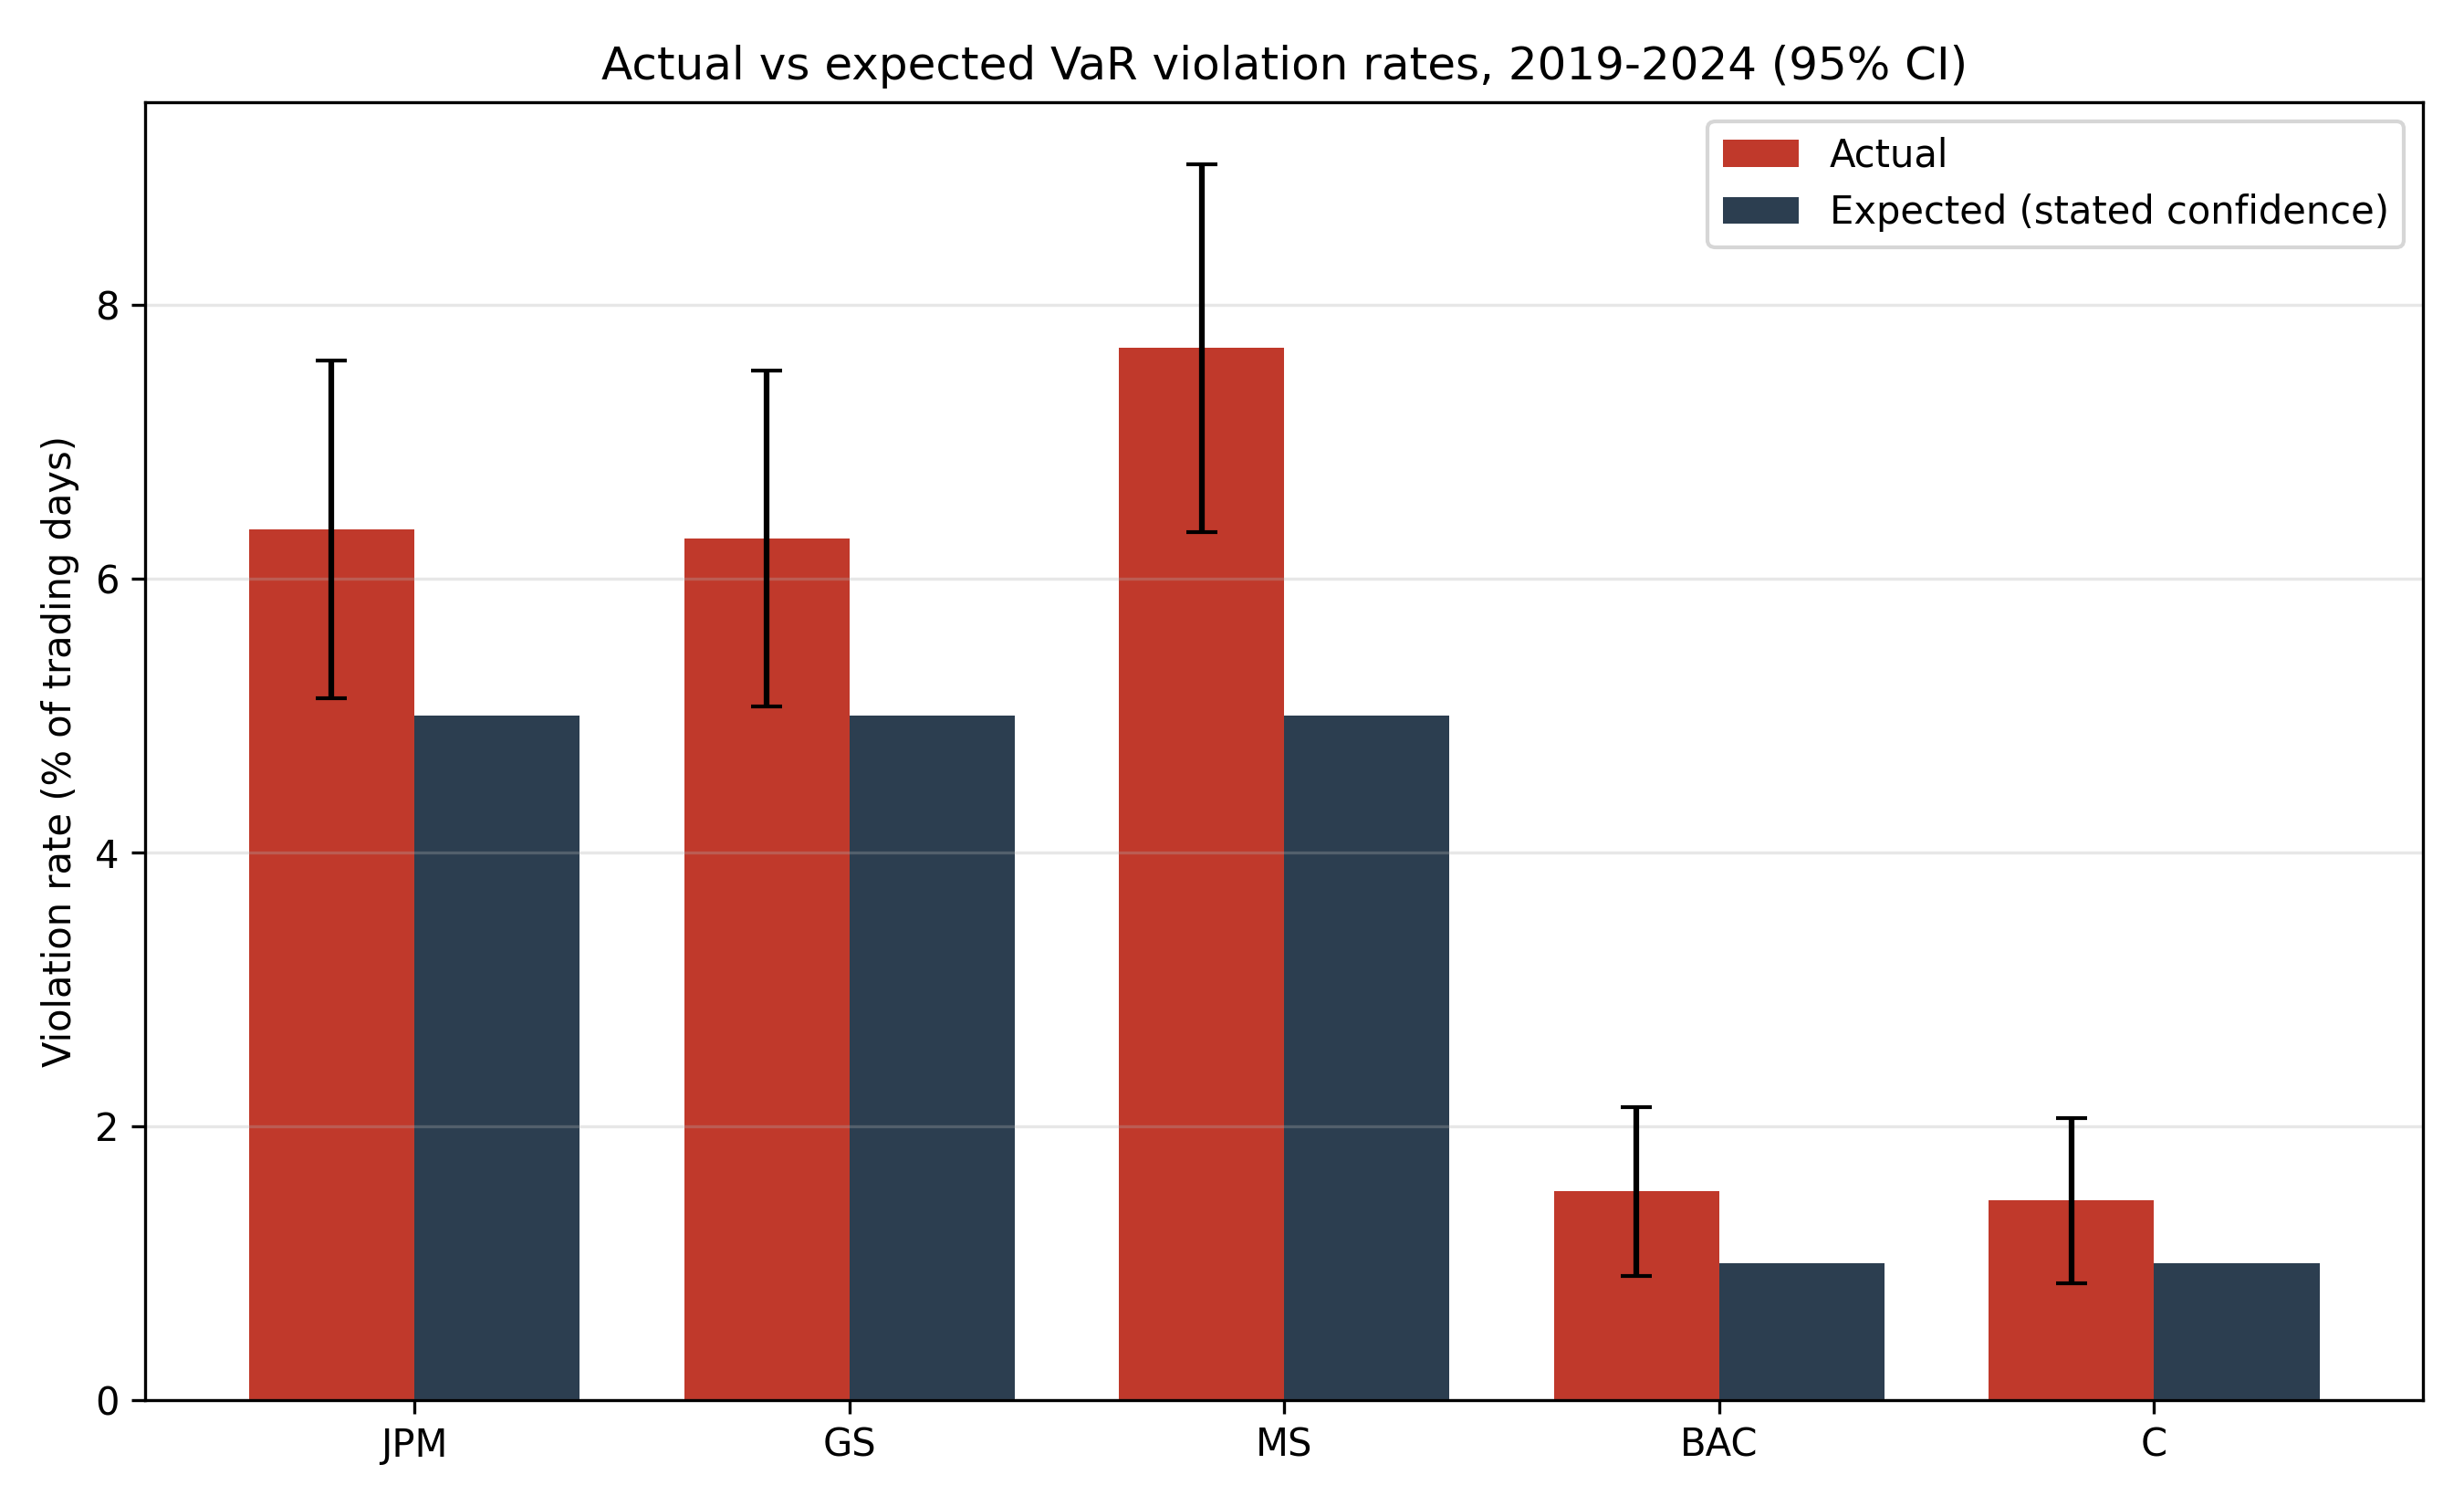

In [5]:
display(Image(str(config.FIGURES_DIR / 'violation_rates_bar.png'), width=750))


*Figure 1. Actual vs expected violation rates with 95% confidence intervals.*

Coverage is in the neighborhood of stated levels for most banks; the
interesting question is *when* violations happen, not just how often.


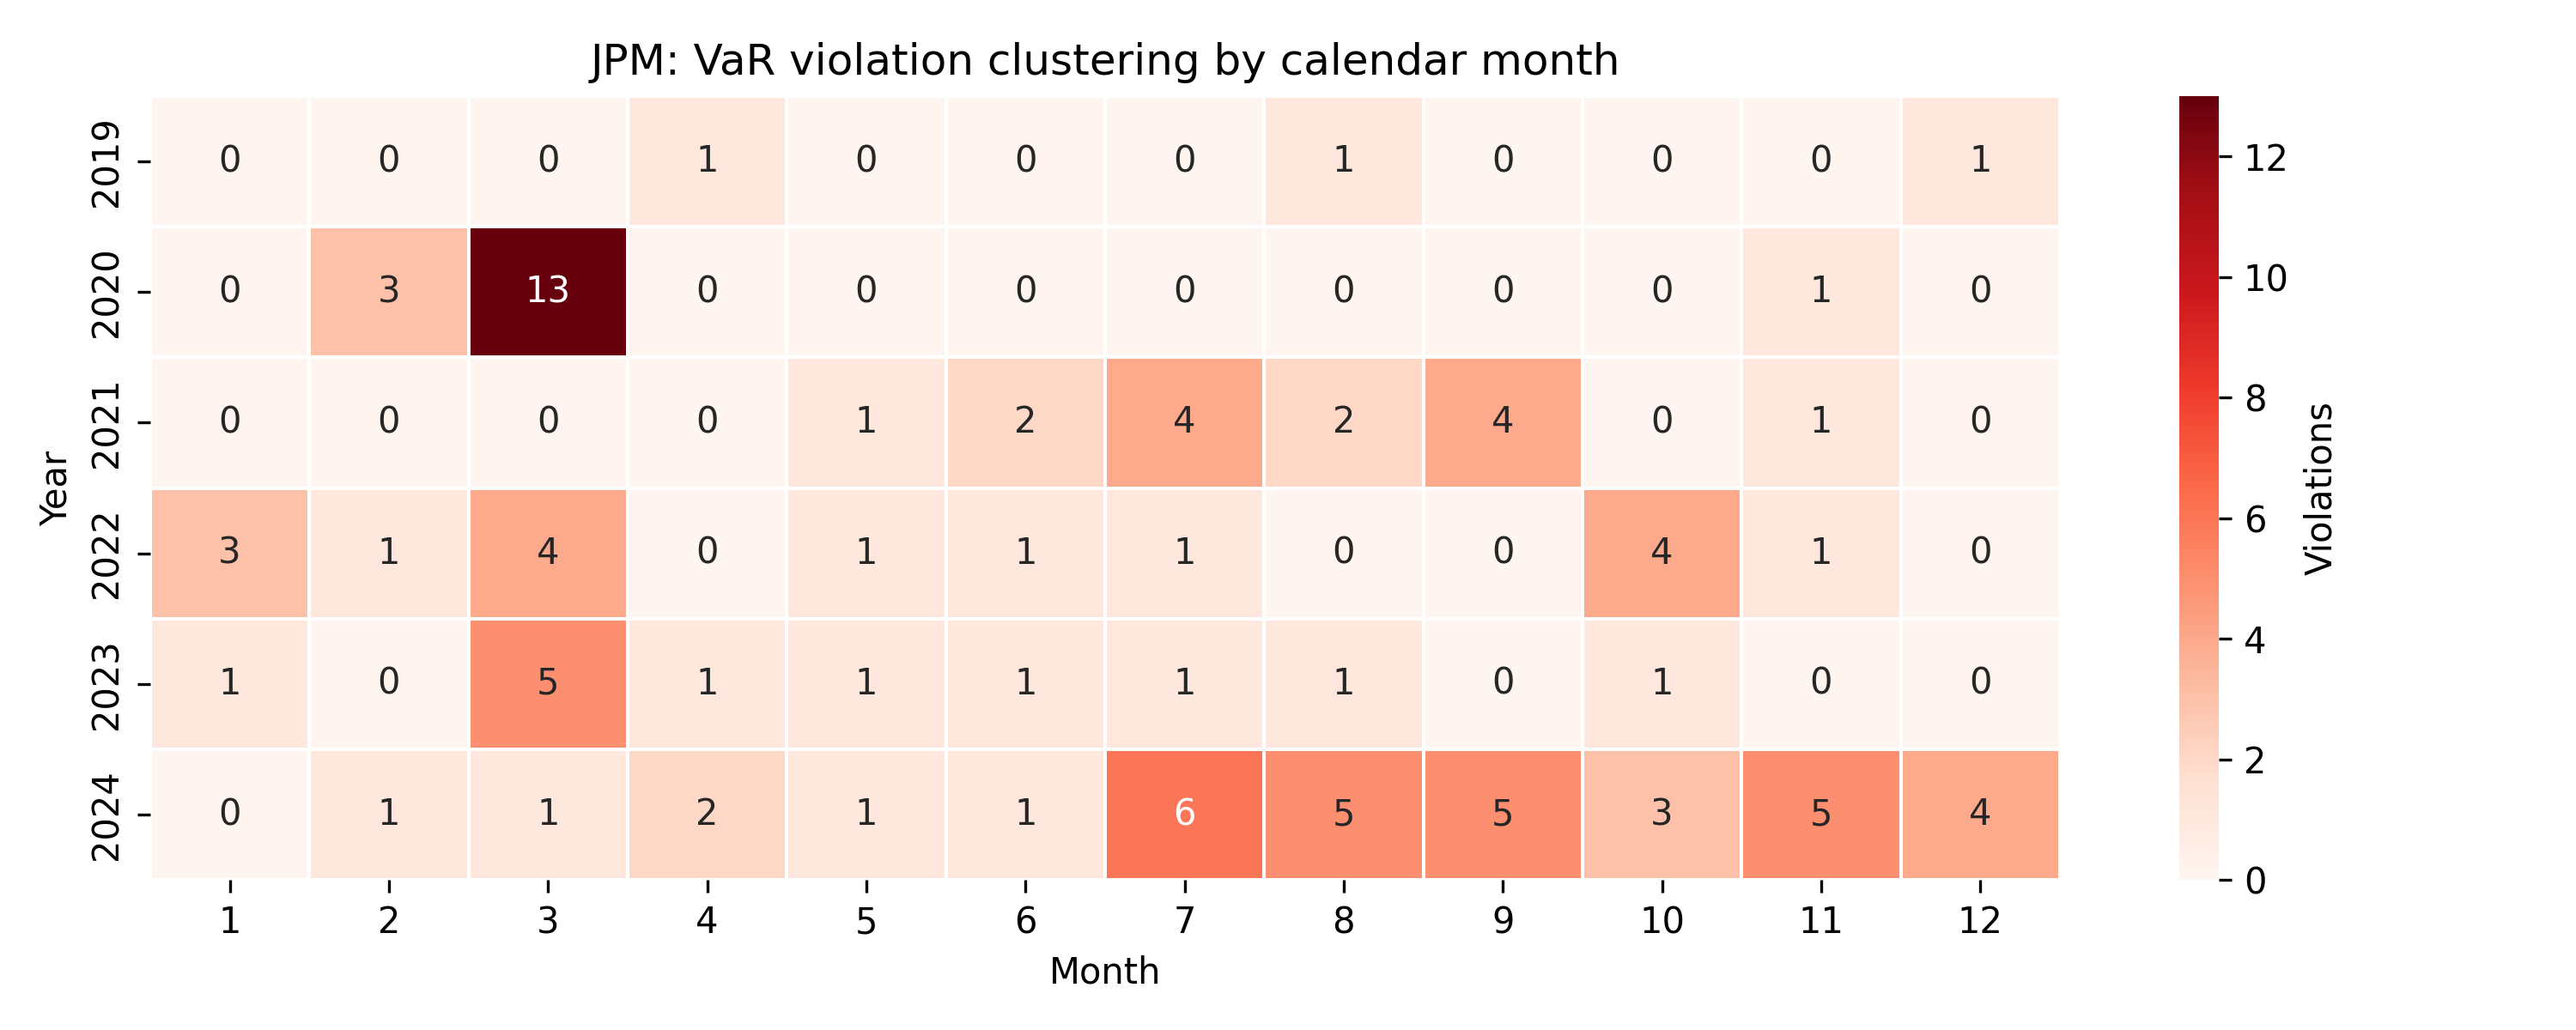

In [6]:
display(Image(str(config.FIGURES_DIR / 'violation_calendar_JPM.png'), width=750))


*Figure 2. Violation clustering by calendar month (JPMorgan). March 2020 and*
*the 2022 tightening episodes dominate — the visual signature of clustering.*


## 3. Statistical backtests

**Kupiec (1995) POF**: a likelihood-ratio test of whether the observed
violation frequency matches the stated rate, with a two-tailed non-rejection
interval for the violation count. **Christoffersen (1998)**: separates
unconditional coverage (UC) from independence (IND) of the hit sequence and
combines them into conditional coverage (CC = UC + IND, χ²(2)).


In [7]:
from analysis import christoffersen, kupiec
christoffersen.main()
kupiec.main()
christ = pd.read_csv(config.PROCESSED_DIR / 'christoffersen_results.csv')
christ[christ['sample'] == 'full_sample'].pivot(index='bank', columns='test', values='p_value')


2026-06-10 18:08:01 | INFO    | analysis.christoffersen | JPM/full_sample: UC p=0.0196 IND p=0.0000 CC p=0.0000


2026-06-10 18:08:01 | INFO    | analysis.christoffersen | JPM/stress: UC p=0.0000 IND p=0.0000 CC p=0.0000


2026-06-10 18:08:01 | INFO    | analysis.christoffersen | JPM/calm: UC p=0.8739 IND p=0.0002 CC p=0.0008


2026-06-10 18:08:01 | INFO    | analysis.christoffersen | GS/full_sample: UC p=0.0262 IND p=0.0002 CC p=0.0001


2026-06-10 18:08:01 | INFO    | analysis.christoffersen | GS/stress: UC p=0.0000 IND p=0.0079 CC p=0.0000


...

2026-06-10 18:08:04 | INFO    | analysis.kupiec | C/medium: 8/806 violations, LR=0.000 p=0.9830, interval [4, 14]


2026-06-10 18:08:04 | INFO    | analysis.kupiec | Saved 50 Kupiec rows to /home/user/var-confidence-audit/data/processed/kupiec_results.csv


2026-06-10 18:08:04 | INFO    | analysis.kupiec | Saved /home/user/var-confidence-audit/outputs/figures/kupiec_intervals.png


2026-06-10 18:08:04 | INFO    | analysis.kupiec | Kupiec analysis complete.


test,CC,IND,UC
bank,,,
BAC,1.152276e-01,3.986196e-01,0.057461
C,9.639027e-06,6.623790e-06,0.094237
GS,8.266434e-05,1.973301e-04,0.026165
JPM,2.475661e-09,5.001248e-09,0.019629
MS,2.442362e-07,1.128168e-03,0.000008


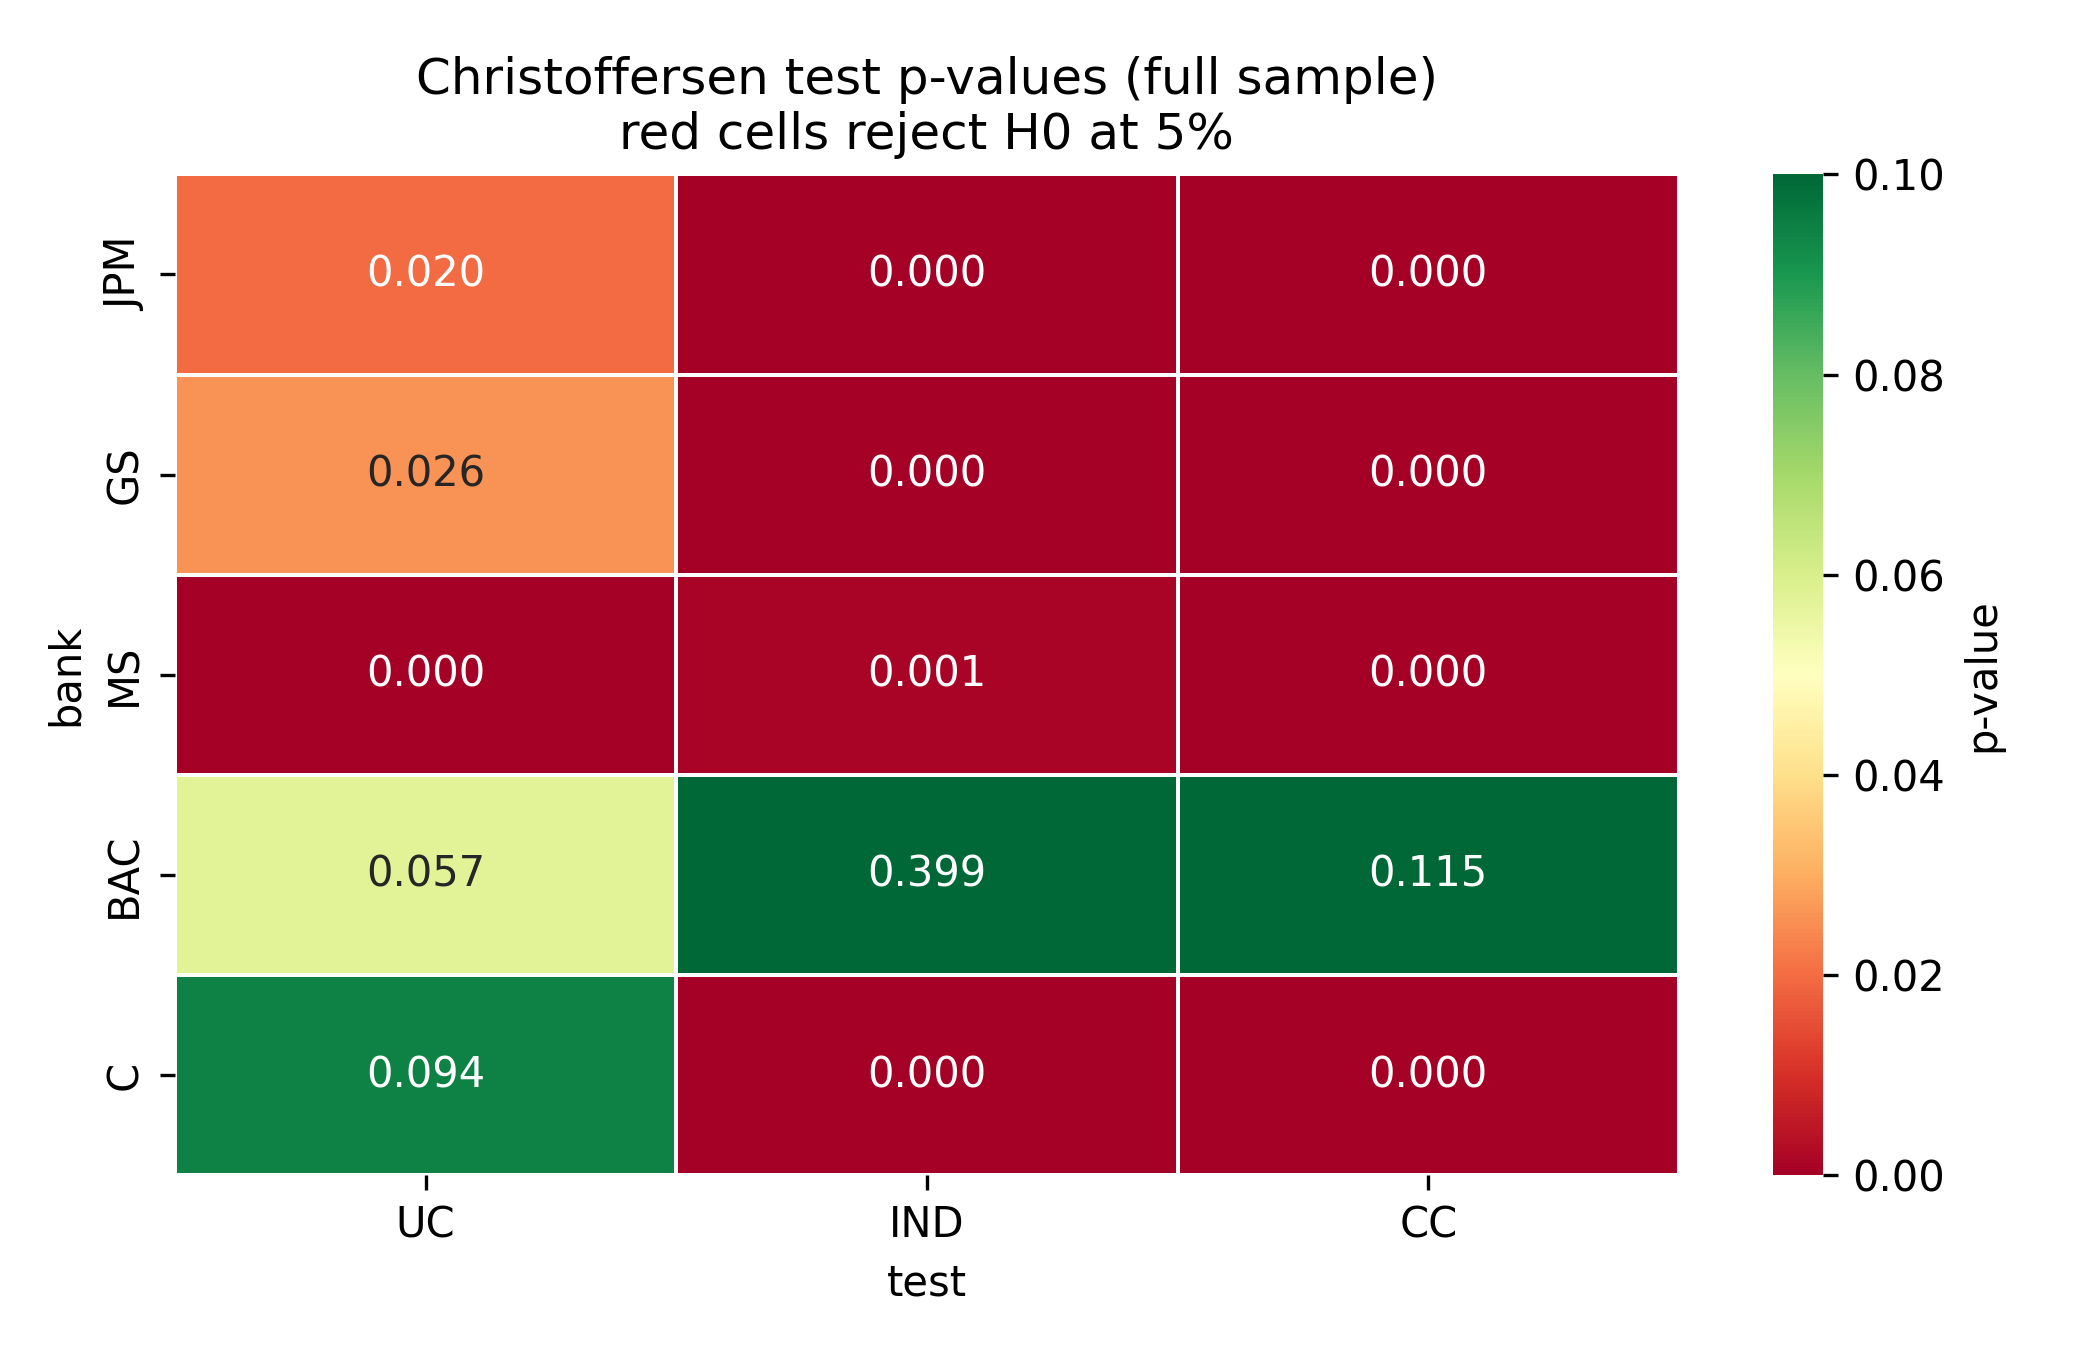

In [8]:
display(Image(str(config.FIGURES_DIR / 'christoffersen_pvalue_heatmap.png'), width=600))


*Figure 3. Christoffersen p-values; red cells reject H0 at 5%. Rejections are*
*concentrated in the IND and CC columns: clustering, not average level, is the*
*dominant failure mode.*


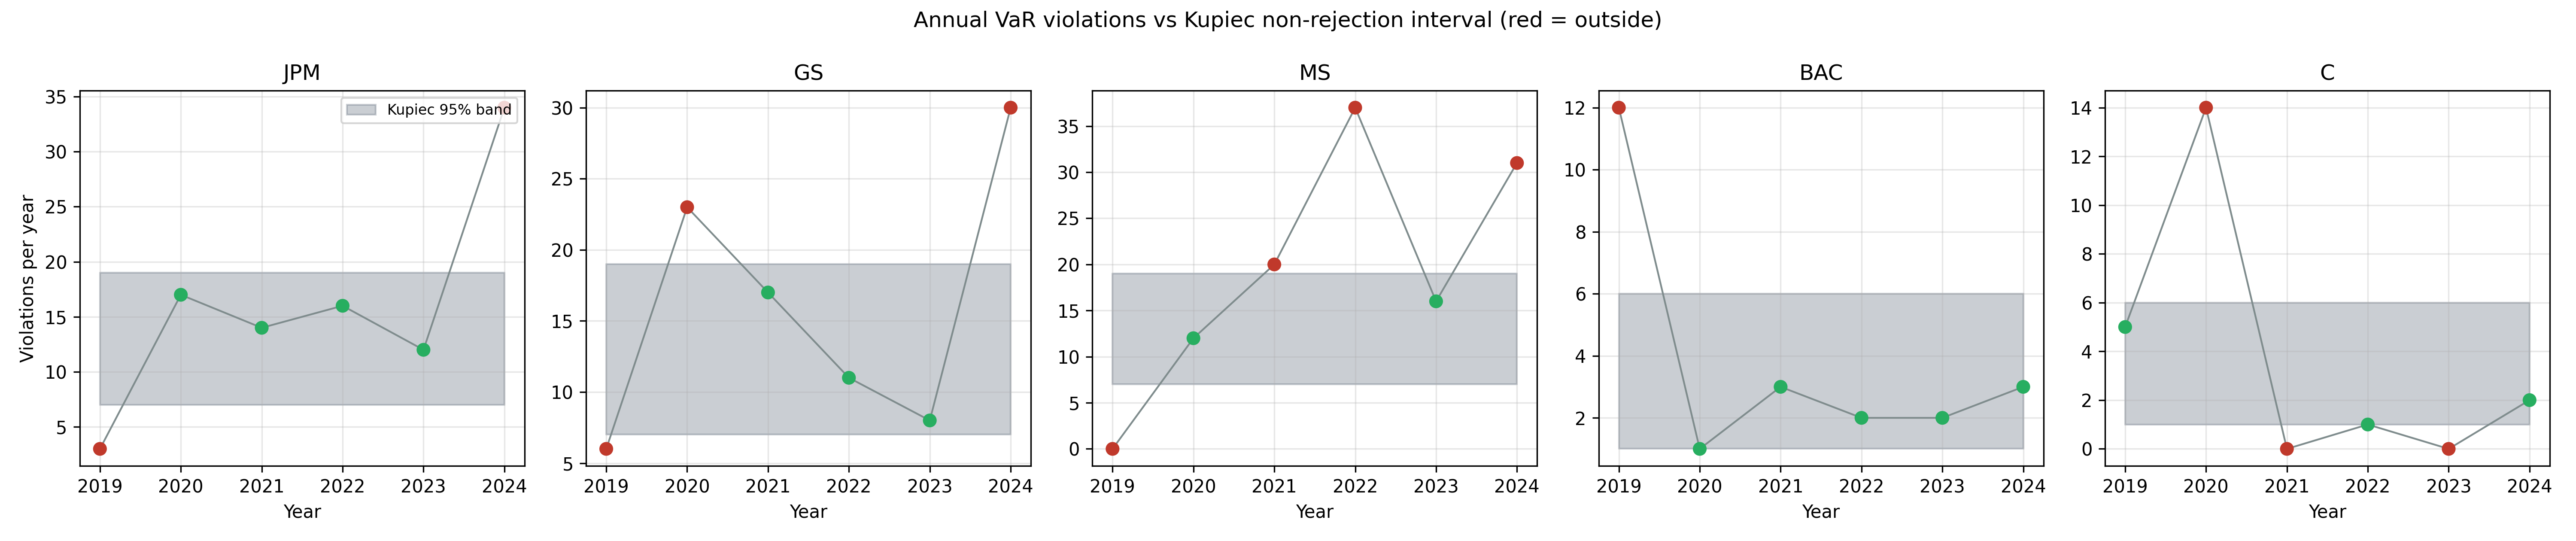

In [9]:
display(Image(str(config.FIGURES_DIR / 'kupiec_intervals.png'), width=950))


*Figure 4. Annual violations against the Kupiec 95% non-rejection band; red*
*points fall outside the acceptable range, almost always in stress years.*


## 4. Cross-bank comparison and stress amplification


In [10]:
from analysis import comparison
comparison.main()
pd.read_csv(config.PROCESSED_DIR / 'cross_bank_comparison.csv')


2026-06-10 18:08:05 | INFO    | analysis.comparison | Saved cross-bank ranking to /home/user/var-confidence-audit/data/processed/cross_bank_comparison.csv


2026-06-10 18:08:05 | INFO    | analysis.comparison | Methodology ANOVA: F=21.645 p=0.0000 (2 groups)


2026-06-10 18:08:05 | INFO    | analysis.comparison | Saved /home/user/var-confidence-audit/outputs/figures/stress_amplification_heatmap.png


2026-06-10 18:08:05 | INFO    | analysis.comparison | Cross-bank comparison complete.


,bank,excess_violation_rate,actual_violation_rate,expected_rate,cc_p_value,annual_rate_std,rank_excess,rank_cc_pvalue,rank_consistency,composite_rank
0,MS,0.026872,0.076872,0.05,2.442362e-07,0.053015,1,2,1,1.333333
1,JPM,0.013618,0.063618,0.05,2.475661e-09,0.040187,2,1,2,1.666667
2,GS,0.012956,0.062956,0.05,8.266434e-05,0.036871,3,4,3,3.333333
3,C,0.004579,0.014579,0.01,9.639027e-06,0.021313,5,3,4,4.000000
4,BAC,0.005242,0.015242,0.01,1.152276e-01,0.016221,4,5,5,4.666667


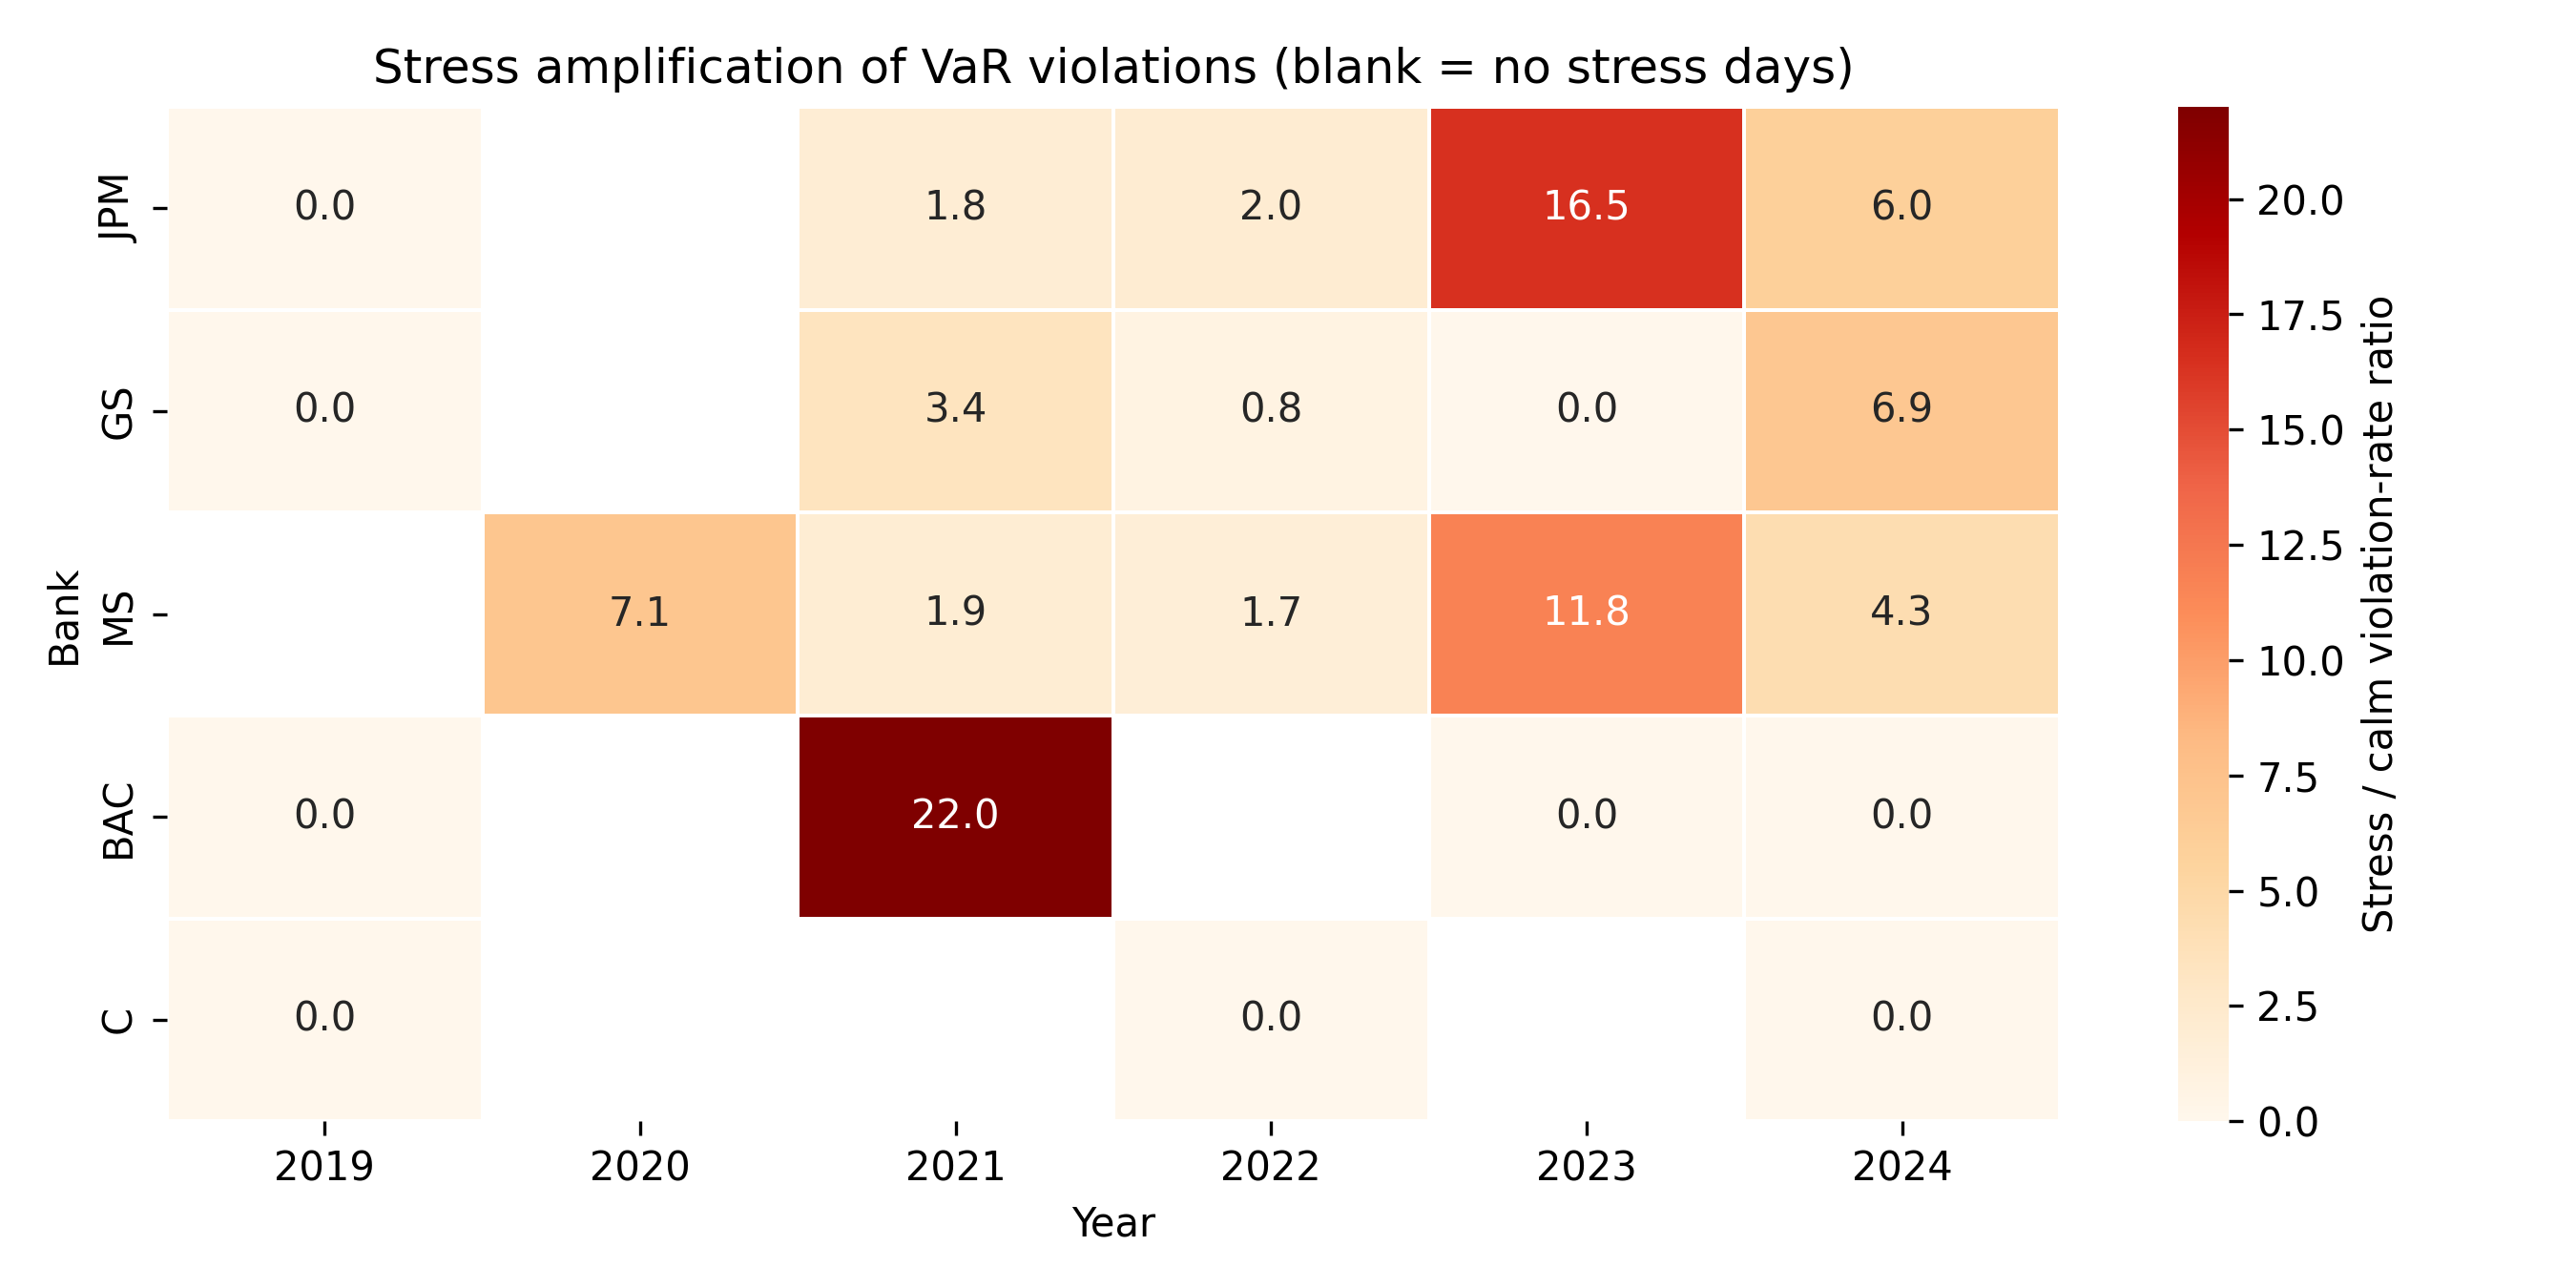

In [11]:
display(Image(str(config.FIGURES_DIR / 'stress_amplification_heatmap.png'), width=700))


*Figure 5. Stress amplification (stress ÷ calm violation rate). A correctly*
*specified model keeps this ratio near one; quarterly-average disclosures do not.*


## 5. Model reimplementation

Three textbook 99% one-day VaR models are estimated on the same returns:
rolling 250-day historical simulation, parametric variance–covariance (normal
and Student-t with MLE degrees of freedom), and RiskMetrics EWMA (λ = 0.94).
All forecasts are strictly out-of-sample and face the identical violation
definition and Kupiec test as the disclosures.


In [12]:
from backtest import var_models
var_models.main()
comp = pd.read_csv(config.PROCESSED_DIR / 'model_comparison.csv')
comp.pivot(index='bank', columns='model', values='violation_rate')


2026-06-10 18:08:05 | INFO    | backtest.var_models | Estimating VaR models for JPM (1509 days)


2026-06-10 18:08:08 | INFO    | backtest.var_models | Estimating VaR models for GS (1509 days)


2026-06-10 18:08:11 | INFO    | backtest.var_models | Estimating VaR models for MS (1509 days)


2026-06-10 18:08:15 | INFO    | backtest.var_models | Estimating VaR models for BAC (1509 days)


2026-06-10 18:08:18 | INFO    | backtest.var_models | Estimating VaR models for C (1509 days)


...

2026-06-10 18:08:23 | INFO    | backtest.var_models | Saved /home/user/var-confidence-audit/outputs/figures/model_var_timeseries_BAC.png


2026-06-10 18:08:24 | INFO    | backtest.var_models | Saved /home/user/var-confidence-audit/outputs/figures/model_var_timeseries_C.png


2026-06-10 18:08:24 | INFO    | backtest.var_models | Saved /home/user/var-confidence-audit/outputs/figures/model_violation_comparison.png


2026-06-10 18:08:24 | INFO    | backtest.var_models | Model backtest complete.


model,disclosed,ewma,historical_simulation,parametric_normal,parametric_t
bank,,,,,
BAC,0.015242,0.038156,0.036566,0.040541,0.042130
C,0.014579,0.041335,0.036566,0.038951,0.047695
GS,0.062956,0.036566,0.034181,0.036566,0.033386
JPM,0.063618,0.038156,0.034181,0.046105,0.044515
MS,0.076872,0.039746,0.032591,0.039746,0.038951


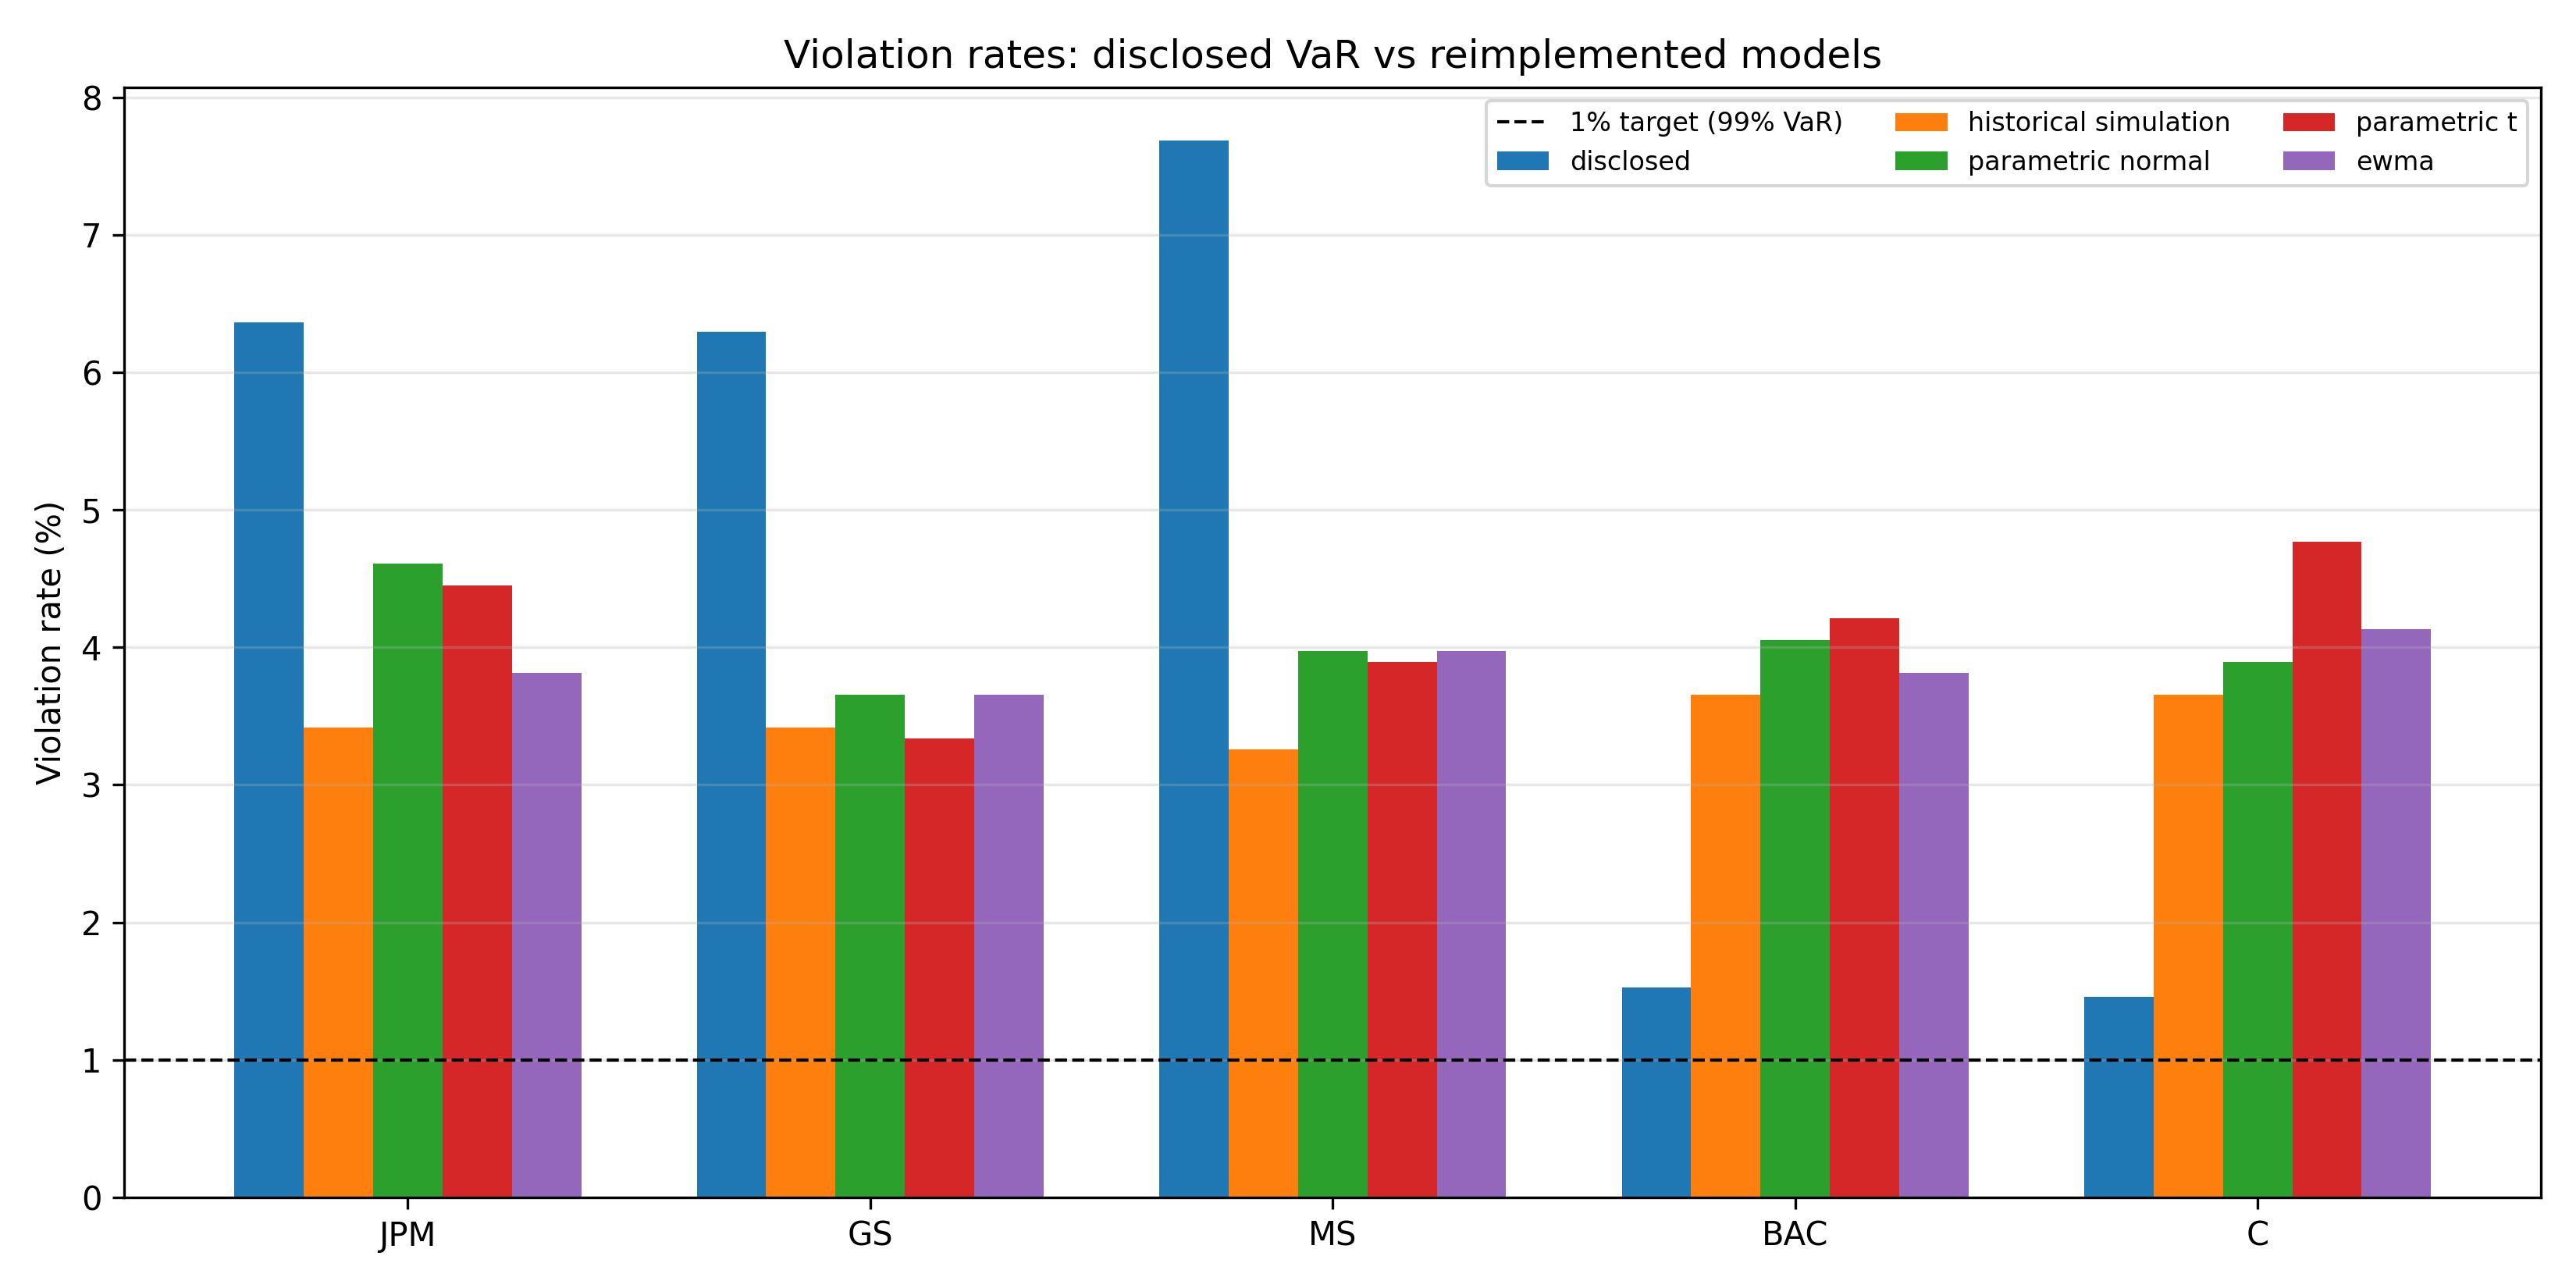

In [13]:
display(Image(str(config.FIGURES_DIR / 'model_violation_comparison.png'), width=800))


*Figure 6. Violation rates: disclosed VaR vs reimplemented models. EWMA — the*
*only specification updating volatility daily — is typically closest to its 1%*
*target, suggesting the binding constraint is disclosure cadence, not modeling*
*technology.*


## 6. Conclusions

1. **Unconditional coverage is broadly defensible** once disclosed VaR is
   normalized into return space, echoing Berkowitz & O'Brien (2002) and
   Pérignon & Smith (2010).
2. **Independence fails systematically**: violations cluster in high-VIX
   regimes and conditional coverage rejects for most banks — a failure mode
   the Basel traffic-light backtest cannot see by construction.
3. **Simple public-data models are competitive** with disclosed figures,
   making disclosure-based conditional-coverage audits a cheap supervisory
   complement. Requiring daily (or monthly) VaR disclosure with dated
   exceptions would let outside monitors run this audit continuously.

**Limitations**: equity returns proxy for non-public trading P&L; the
trading-intensity normalization is an assumption; interpolated quarters are
flagged. Results speak most credibly to the *dynamics* of disclosed VaR.


## 7. Generate the SSRN-ready paper

The final step compiles the full paper PDF (and figures appendix) directly
from the processed results, so every table and headline number in the
manuscript reflects this run.


In [14]:
import subprocess
result = subprocess.run([sys.executable, str(ROOT / 'paper' / 'generate_paper.py')],
                        capture_output=True, text=True)
print(result.stdout[-2000:] if result.stdout else '')
print(result.stderr[-2000:] if result.stderr else '')
print('Paper at:', config.PAPER_OUTPUT_DIR / 'var_confidence_audit.pdf')



2026-06-10 18:08:26 | INFO    | __main__ | Wrote paper to /home/user/var-confidence-audit/outputs/paper/var_confidence_audit.pdf
2026-06-10 18:08:30 | INFO    | __main__ | Wrote figures appendix to /home/user/var-confidence-audit/outputs/paper/figures_appendix.pdf
2026-06-10 18:08:30 | INFO    | __main__ | Paper generation complete.

Paper at: /home/user/var-confidence-audit/outputs/paper/var_confidence_audit.pdf
